In [ ]:
# Import initial 3rd party libraries
import sys
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import kagglehub
import json

# Configure Notebook
# %matplotlib inline
plt.style.use('fivethirtyeight')
sns.set_context("notebook")
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load the metadata
data_path = "../../datasets/input/"
df_meta = pd.read_csv(data_path+"movies_metadata.csv")
df_meta = df_meta[["id", "title"]]
df_meta["id"] = pd.to_numeric(df_meta["id"], errors="coerce") 
df_meta = df_meta.dropna(subset=["id"]).astype({"id": int}) 
df_meta = df_meta.dropna(subset=["title"]) 
df_meta = df_meta.drop_duplicates(subset=['id'],keep='first')

# Load the metadata
df_ratings = pd.read_csv(data_path+"ratings_small.csv")
df_ratings = df_ratings[["userId", "movieId", "rating"]]
df_ratings = df_ratings.dropna(subset=["userId", "movieId", "rating"])
df_ratings["userId"] = df_ratings["userId"].astype(int) 
df_ratings["movieId"] = df_ratings["movieId"].astype(int) 
df_ratings["rating"] = df_ratings["rating"].astype(float) 
# If there are duplicate <userId, movieId> pairs, average them. Unlikely tho 
df_ratings = df_ratings.groupby(["userId", "movieId"], as_index=False)["rating"].mean()


df_links = pd.read_csv(data_path+"links_small.csv") 
df_links = df_links[["movieId", "tmdbId"]]
df_links["tmdbId"] = pd.to_numeric(df_links["tmdbId"], errors="coerce") 
df_links = df_links.dropna(subset=["tmdbId"]).astype({"tmdbId": int}) 

In [ ]:
#Explore

In [ ]:
n_ratings = len(df_ratings)
n_movies = df_ratings['movieId'].nunique()
n_users = df_ratings['userId'].nunique()

print(f"Number of ratings: {n_ratings}")
print(f"Number of unique movieId's: {n_movies}")
print(f"Number of unique users: {n_users}")
print(f"Average number of ratings per user: {round(n_ratings/n_users, 2)}")
print(f"Average number of ratings per movie: {round(n_ratings/n_movies, 2)}")



Number of ratings: 100004
Number of unique movieId's: 9066
Number of unique users: 671
Average number of ratings per user: 149.04
Average number of ratings per movie: 11.03


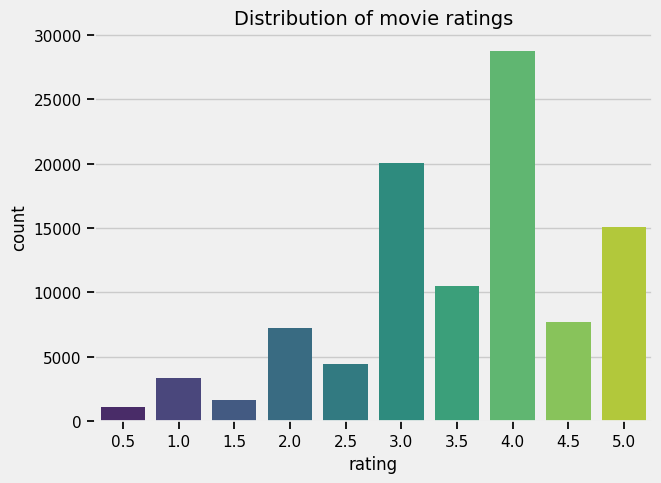

In [ ]:
sns.countplot(x="rating", data=df_ratings, palette="viridis")
plt.title("Distribution of movie ratings", fontsize=14)
plt.show()



In [ ]:
print(f"Mean global rating: {round(df_ratings['rating'].mean(),2)}.")

mean_ratings = df_ratings.groupby('userId')['rating'].mean()
print(f"Mean rating per user: {round(mean_ratings.mean(),2)}.")

Mean global rating: 3.54.
Mean rating per user: 3.66.


In [ ]:
# add title to links
df_links2 = df_links.merge(df_meta, left_on='tmdbId',right_on='id').drop(columns=['tmdbId','id'])
df_links2.head()


,movieId,title
0,1,Toy Story
1,2,Jumanji
2,3,Grumpier Old Men
3,4,Waiting to Exhale
4,5,Father of the Bride Part II


In [ ]:
#Which movies are most frequently rated?

movie_ratings = df_ratings.merge(df_links2, on='movieId')
movie_ratings['title'].value_counts()[0:10]

title
Forrest Gump                  341
Pulp Fiction                  324
The Shawshank Redemption      311
The Silence of the Lambs      304
Star Wars                     291
Jurassic Park                 274
The Matrix                    259
Toy Story                     247
Schindler's List              244
Terminator 2: Judgment Day    237
Name: count, dtype: int64

In [ ]:

# What are the lowest and highest rated movies?

# Which movie has the lowest and highest average rating?

mean_ratings = df_ratings.groupby('movieId')[['rating']].mean()
lowest_rated = mean_ratings['rating'].idxmin()
df_links2[df_links2['movieId']==lowest_rated]



,movieId,title
1058,1311,Santa with Muscles


In [ ]:
highest_rated = mean_ratings['rating'].idxmax()
df_links2[df_links2['movieId'] == highest_rated]

,movieId,title
50,53,Lamerica


In [ ]:
df_ratings[df_ratings['movieId']==highest_rated]

,userId,movieId,rating
46719,344,53,5.0


In [ ]:
df_ratings[df_ratings['movieId']==lowest_rated]

,userId,movieId,rating
87420,581,1311,0.5


In [ ]:
# A better approach for evaluating movie popularity is to do look at the Bayesian average.
movie_stats = df_ratings.groupby('movieId')['rating'].agg(['count', 'mean'])
movie_stats.head()

,count,mean
movieId,,
1,247,3.872470
2,107,3.401869
3,59,3.161017
4,13,2.384615
5,56,3.267857


In [ ]:
C = movie_stats['count'].mean()
m = movie_stats['mean'].mean()

print(f"Average number of ratings for a given movie: {C:.2f}")
print(f"Average rating for a given movie: {m:.2f}")

def bayesian_avg(ratings):
    bayesian_avg = (C*m+ratings.sum())/(C+ratings.count())
    return round(bayesian_avg, 3)


Average number of ratings for a given movie: 11.03
Average rating for a given movie: 3.29


In [ ]:
lamerica = pd.Series([5.0])
bayesian_avg(lamerica)

3.434

In [ ]:
# Let's now apply bayesian_avg to all movies in our dataset.

bayesian_avg_ratings = df_ratings.groupby('movieId')['rating'].agg(bayesian_avg).reset_index()
bayesian_avg_ratings.columns = ['movieId', 'bayesian_avg']
movie_stats = movie_stats.merge(bayesian_avg_ratings, on='movieId')

movie_stats = movie_stats.merge(df_links2[['movieId', 'title']])
movie_stats.sort_values('bayesian_avg', ascending=False).head()



,movieId,count,mean,bayesian_avg,title
284,318,311,4.487138,4.446,The Shawshank Redemption
692,858,200,4.487500,4.425,The Godfather
48,50,201,4.370647,4.315,The Usual Suspects
973,1221,135,4.385185,4.303,The Godfather: Part II
472,527,244,4.303279,4.260,Schindler's List


In [ ]:
# bad movies
movie_stats.sort_values('bayesian_avg', ascending=True).head()

,movieId,count,mean,bayesian_avg,title
2864,3593,19,1.210526,1.975,Battlefield Earth
1238,1556,23,1.652174,2.184,Speed 2: Cruise Control
2157,2701,47,2.031915,2.271,Wild Wild West
489,546,17,1.735294,2.348,Super Mario Bros.
1239,1562,47,2.148936,2.366,Batman & Robin


In [ ]:
# The create_X() function outputs a sparse matrix X with four mapper dictionaries:

#     user_mapper: maps user id to user index
#     movie_mapper: maps movie id to movie index
#     user_inv_mapper: maps user index to user id
#     movie_inv_mapper: maps movie index to movie id

# We need these dictionaries because they map which row/column of the utility matrix corresponds to which user/movie id.

# Our X (user-item) matrix is a scipy.sparse.csr_matrix which stores the data sparsely.

In [ ]:
from scipy.sparse import csr_matrix

def create_X(df):
    """
    Generates a sparse matrix from ratings dataframe.
    
    Args:
        df: pandas dataframe containing 3 columns (userId, movieId, rating)
    
    Returns:
        X: sparse matrix
        user_mapper: dict that maps user id's to user indices
        user_inv_mapper: dict that maps user indices to user id's
        movie_mapper: dict that maps movie id's to movie indices
        movie_inv_mapper: dict that maps movie indices to movie id's
    """
    M = df['userId'].nunique()
    N = df['movieId'].nunique()

    user_mapper = dict(zip(np.unique(df["userId"]), list(range(M))))
    movie_mapper = dict(zip(np.unique(df["movieId"]), list(range(N))))
    
    user_inv_mapper = dict(zip(list(range(M)), np.unique(df["userId"])))
    movie_inv_mapper = dict(zip(list(range(N)), np.unique(df["movieId"])))
    
    user_index = [user_mapper[i] for i in df['userId']]
    item_index = [movie_mapper[i] for i in df['movieId']]

    X = csr_matrix((df["rating"], (user_index,item_index)), shape=(M,N))
    
    return X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper

X, user_mapper, movie_mapper, user_inv_mapper, movie_inv_mapper = create_X(df_ratings)

In [ ]:
X.shape

(671, 9066)

In [ ]:

# Evaluating sparsity

# Here, we calculate sparsity by dividing the number of stored elements by total number of elements. 
# The number of stored (non-empty) elements in our matrix (nnz) is equivalent to the number of ratings in our dataset.

n_total = X.shape[0]*X.shape[1]
n_ratings = X.nnz
sparsity = n_ratings/n_total
print(f"Matrix sparsity: {round(sparsity*100,2)}%")



Matrix sparsity: 1.64%


In [ ]:
# The cold start problem is when there are new users and movies in our matrix that do not have any ratings. 
# In our movie dataset, all users and movies have at least one rating but in general, it's useful to check which users and movies have few interactions.

n_ratings_per_user = X.getnnz(axis=1)
len(n_ratings_per_user)



671

In [ ]:
print(f"Most active user rated {n_ratings_per_user.max()} movies.")
print(f"Least active user rated {n_ratings_per_user.min()} movies.")

Most active user rated 2391 movies.
Least active user rated 20 movies.


In [ ]:
n_ratings_per_movie = X.getnnz(axis=0)
len(n_ratings_per_movie)

9066

In [ ]:
print(f"Most rated movie has {n_ratings_per_movie.max()} ratings.")
print(f"Least rated movie has {n_ratings_per_movie.min()} ratings.")

Most rated movie has 341 ratings.
Least rated movie has 1 ratings.


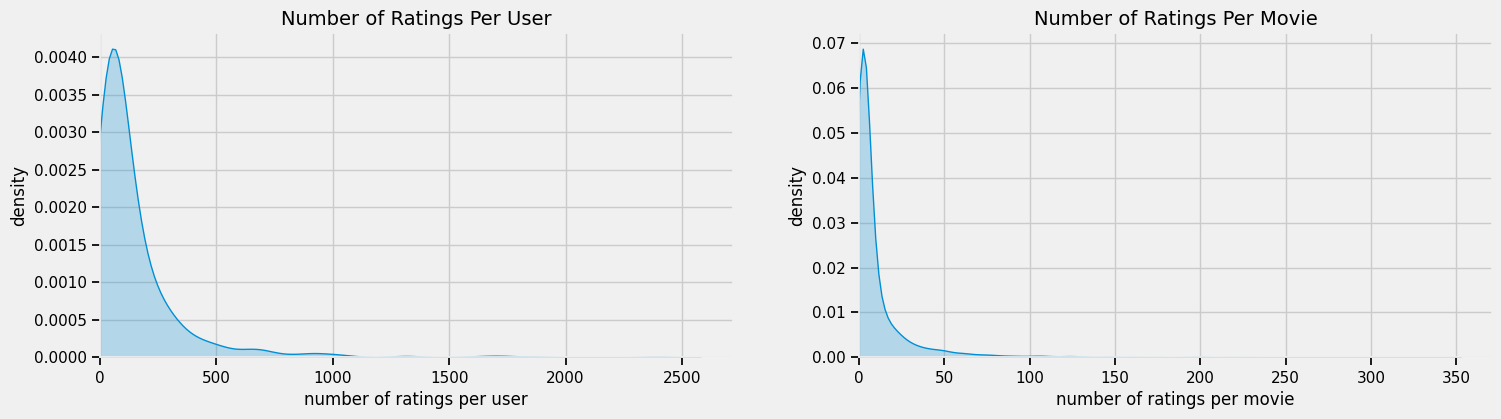

In [ ]:
plt.figure(figsize=(16,4))
plt.subplot(1,2,1)
sns.kdeplot(n_ratings_per_user, shade=True)
plt.xlim(0)
plt.title("Number of Ratings Per User", fontsize=14)
plt.xlabel("number of ratings per user")
plt.ylabel("density")
plt.subplot(1,2,2)
sns.kdeplot(n_ratings_per_movie, shade=True)
plt.xlim(0)
plt.title("Number of Ratings Per Movie", fontsize=14)
plt.xlabel("number of ratings per movie")
plt.ylabel("density")
plt.show()

In [ ]:
# Item-item Recommendations with k-Nearest Neighbors

# We are going to find the
# movies that have the most similar user engagement vectors for movie

from sklearn.neighbors import NearestNeighbors

def find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, k, metric='cosine'):
    """
    Finds k-nearest neighbours for a given movie id.
    
    Args:
        movie_id: id of the movie of interest
        X: user-item utility matrix
        k: number of similar movies to retrieve
        metric: distance metric for kNN calculations
    
    Output: returns list of k similar movie ID's
    """
    X = X.T
    neighbour_ids = []
    
    movie_ind = movie_mapper[movie_id]
    movie_vec = X[movie_ind]
    if isinstance(movie_vec, (np.ndarray)):
        movie_vec = movie_vec.reshape(1,-1)
    # use k+1 since kNN output includes the movieId of interest
    kNN = NearestNeighbors(n_neighbors=k+1, algorithm="brute", metric=metric)
    kNN.fit(X)
    neighbour = kNN.kneighbors(movie_vec, return_distance=False)
    for i in range(0,k):
        n = neighbour.item(i)
        neighbour_ids.append(movie_inv_mapper[n])
    neighbour_ids.pop(0)
    return neighbour_ids



In [ ]:
similar_movies = find_similar_movies(1, X, movie_mapper, movie_inv_mapper, k=10)
similar_movies

[3114, 260, 356, 780, 1265, 1270, 480, 4306, 1210]

In [ ]:
movie_titles = dict(zip(df_links2['movieId'], df_links2['title']))

movie_id = 1

similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='cosine', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])

Because you watched Toy Story:
Toy Story 2
Star Wars
Forrest Gump
Independence Day
Groundhog Day
Back to the Future
Jurassic Park
Shrek
Return of the Jedi


In [ ]:
# Different metric
movie_id = 1

similar_movies = find_similar_movies(movie_id, X, movie_mapper, movie_inv_mapper, metric='euclidean', k=10)
movie_title = movie_titles[movie_id]

print(f"Because you watched {movie_title}:")
for i in similar_movies:
    print(movie_titles[i])



Because you watched Toy Story:
Toy Story 2
A Bug's Life
Groundhog Day
Independence Day
Monsters, Inc.
Finding Nemo
The Incredibles
Shrek
Willy Wonka & the Chocolate Factory
